In [46]:
import json
import os
import sys
import time
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from phd.jax_core.tasks.multi_geoff import MultiGEOFFTask
from omegaconf import OmegaConf

from phd.jax_core.utils import configure_jax, stack_pytrees
from phd.research_utils.analysis.analysis_utils import get_color_palette

NOTEBOOK_DIR = os.path.abspath('.')
if NOTEBOOK_DIR not in sys.path:      # make the sibling modules importable
    sys.path.insert(0, NOTEBOOK_DIR)

from masked_mlp import slot_ids
from dynamic_skip_mlp import (
    NO_TASK, DynamicAutostepMLP, block_sparse_skip_masks, dense_skip_masks, group_quantiles,
    initial_structure, n_connections, random_feedback, structure_metrics, task_labels,
)

# The repo's JAX setup: a persistent compilation cache in /tmp/jax_cache, so re-executing an unchanged
# notebook skips every compile.
configure_jax(OmegaConf.create({'device': None}))

sns.set_theme('notebook', 'white')
%matplotlib inline

JAX device not specified, using default: cuda:0


## Configuration

In [47]:
# --- Problem (stationary 8-task multi-GEOFF) ---
N_TASKS = 8
N_FEATURES_PER_TASK = 20
N_OUTPUTS_PER_TASK = 10
NOISE_STD = 1.0
FIRING_PROB = 0.1                # teacher LTU firing probability; None is the original zero-threshold teacher

# --- Network ---
ACTIVATION = 'ltu'
BUDGETS = (480, 960, 1920, 3840, 7680)   # connections per run, biases not counted; one block-sparse run each.
                                         # Block-sparse spends 30 per hidden unit and splits the hidden units
                                         # evenly over the tasks, so each must be a multiple of N_TASKS * 30 = 240
REFERENCE_BUDGET = 1920                  # the dense and linear references run once, at this budget (also a multiple of 240)

# --- Optimizer ---
INIT_LR = 1e-8                   # starting step-size of every connection
INIT_BIAS_LR = 2 ** -4           # starting step-size of the bias columns
INIT_W_INPUT = 1e-8              # input->hidden and skip weights start uniform in (-INIT_W_INPUT, INIT_W_INPUT)
META_LR = 0.02
L1_COEFF = 0.01                 # subgradient L1 inside the gradient Autostep adapts on; biases exempt
GEN_CAP = 512                    # connections generated per step at most; the deficit audit checks it
FEEDBACK_STEPS = 10_000          # 3c: fixed +-1 feedback for this many steps, then plain backpropagation

# --- Training and recording ---
NUM_STEPS = 1_000_000
N_SEEDS = 10                     # vmapped into one scan; one teacher, one structure and one init each
N_SNAPSHOTS = 100                # structure snapshots per run; per-step scalars are averaged per block
QUANTILES = (0.1, 0.25, 0.5, 0.75, 0.9)
BASE_SEED = 0
RERUN = False                    # True recomputes every run instead of loading its cached .npz
DATA_DIR = os.path.join(NOTEBOOK_DIR, 'data')

# --- Derived ---
N_FEATURES = N_TASKS * N_FEATURES_PER_TASK
N_OUTPUTS = N_TASKS * N_OUTPUTS_PER_TASK
INPUT_TASK_IDS = slot_ids(N_TASKS, N_FEATURES_PER_TASK)
OUTPUT_TASK_IDS = slot_ids(N_TASKS, N_OUTPUTS_PER_TASK)
IRREDUCIBLE_MSE = NOISE_STD ** 2         # per-output MSE of an optimal predictor
BASELINE_MSE = IRREDUCIBLE_MSE + 1.0     # the mean predictor sits 1 above it
VIEW_NAMES = ('hidden $\\leftarrow$ inputs', 'outputs $\\leftarrow$ inputs (skips)',
              'outputs $\\leftarrow$ hidden')      # the three kinds of connection, in the module's order
GROUP_NAMES = ('same task', 'cross task')
GROUP_COLORS = ('#3b6fb0', '#c0392b')
os.makedirs(DATA_DIR, exist_ok=True)

## Structures

| structure | budget | shape |
|---|---|---|
| `block_sparse` | one run per entry of `BUDGETS` | each hidden unit fully connected to its own task's inputs and outputs, no skips; 30 connections per hidden unit, split evenly over the tasks, so a budget buys `budget / 240` hidden units per task |
| `dense` | `REFERENCE_BUDGET` | fully connected, no skip connections; `N_FEATURES + N_OUTPUTS` = 240 connections per hidden unit |
| `block_sparse_linear` | `REFERENCE_BUDGET` | every same-task input→output skip connection and nothing else; the hidden units are left disconnected. A random same-task subset if the budget is below their count, and never a cross-task connection |

Every structure carries a bias on every hidden and output unit; biases are not part of the budget.
A structure function returns the masks, the feedback signs (None for the references), and each
hidden unit's task id — or `NO_TASK` for the dense and linear references, whose hidden units belong
to no task and so get no same-task / cross-task labels.


In [48]:
# Block-sparse spends N_FEATURES_PER_TASK + N_OUTPUTS_PER_TASK = 30 connections per hidden unit (its
# task's inputs and outputs), and the hidden units split evenly over the tasks, so a budget buys
# budget / (N_TASKS * 30) hidden units per task. Dense spends N_FEATURES + N_OUTPUTS per hidden unit.
CONNECTIONS_PER_HIDDEN = N_FEATURES_PER_TASK + N_OUTPUTS_PER_TASK
DENSE_HIDDEN = REFERENCE_BUDGET // (N_FEATURES + N_OUTPUTS)
assert DENSE_HIDDEN * (N_FEATURES + N_OUTPUTS) == REFERENCE_BUDGET, REFERENCE_BUDGET


def block_sparse_hidden(budget):
    """The number of hidden units block-sparse gets for `budget` connections."""
    n_hidden = budget // CONNECTIONS_PER_HIDDEN
    assert n_hidden * CONNECTIONS_PER_HIDDEN == budget and n_hidden % N_TASKS == 0, \
        f'budget {budget} is not a multiple of {N_TASKS * CONNECTIONS_PER_HIDDEN}'
    return n_hidden


def block_sparse_structure(budget):
    """The structure function for block-sparse at `budget` connections (the same for every seed)."""
    def structure(key):
        masks, hidden_task_ids = block_sparse_skip_masks(
            N_TASKS, N_FEATURES_PER_TASK, N_OUTPUTS_PER_TASK, block_sparse_hidden(budget))
        return masks, None, hidden_task_ids
    return structure


def dense_structure(key):
    masks = dense_skip_masks(N_FEATURES, DENSE_HIDDEN, N_OUTPUTS)
    return masks, None, jnp.full((DENSE_HIDDEN,), NO_TASK)


N_SAME_TASK_SKIPS = N_TASKS * N_FEATURES_PER_TASK * N_OUTPUTS_PER_TASK
LINEAR_HIDDEN = block_sparse_hidden(REFERENCE_BUDGET)   # disconnected; as many as block-sparse has at that budget
LINEAR_USED = min(REFERENCE_BUDGET, N_SAME_TASK_SKIPS)
DENSE_LABEL = f'dense, {REFERENCE_BUDGET:,} connections ({DENSE_HIDDEN} hidden)'
LINEAR_LABEL = (('block-sparse linear' if REFERENCE_BUDGET >= N_SAME_TASK_SKIPS else 'sparse block-sparse linear')
                + f', {LINEAR_USED:,} connections (no hidden units)')


def block_sparse_linear_structure(key):
    """Every same-task input->output skip connection and nothing else: the hidden units stay
    disconnected, and no cross-task connection is added even when the budget would allow one. If
    `REFERENCE_BUDGET` cannot hold all `N_SAME_TASK_SKIPS` of them, a random same-task subset of budget
    size is drawn per seed."""
    same = (OUTPUT_TASK_IDS[:, None] == INPUT_TASK_IDS[None, :]).astype(jnp.float32)
    if REFERENCE_BUDGET < N_SAME_TASK_SKIPS:
        # Rank the same-task positions in a random order and keep the first REFERENCE_BUDGET of them.
        noise = jnp.where(same > 0, jax.random.uniform(key, same.shape), jnp.inf).reshape(-1)
        rank = jnp.argsort(jnp.argsort(noise)).reshape(same.shape)
        same = same * (rank < REFERENCE_BUDGET)
    masks = {'w1': jnp.zeros((LINEAR_HIDDEN, N_FEATURES + 1)).at[:, -1].set(1.0),
             'w2': jnp.concatenate([same, jnp.zeros((N_OUTPUTS, LINEAR_HIDDEN)), jnp.ones((N_OUTPUTS, 1))],
                                   axis=1)}
    return masks, None, jnp.full((LINEAR_HIDDEN,), NO_TASK)


def describe(name, masks):
    n_hidden, n_features = masks['w1'].shape[0], masks['w1'].shape[1] - 1
    print(f'{name:13s} {n_connections(masks):5d} connections   {n_hidden:3d} hidden units   '
          f'{float(masks["w1"][:, :n_features].sum()) / n_hidden:5.1f} inputs per hidden unit   '
          f'{float(masks["w2"][:, :n_features].sum()) / N_OUTPUTS:5.1f} skips per output unit')


for budget in BUDGETS:
    masks, _, _ = block_sparse_structure(budget)(jax.random.PRNGKey(BASE_SEED))
    assert n_connections(masks) == budget, (budget, n_connections(masks))
    describe('block-sparse', masks)
describe('dense', dense_structure(jax.random.PRNGKey(BASE_SEED))[0])
describe('linear', block_sparse_linear_structure(jax.random.PRNGKey(BASE_SEED))[0])

print(f'\nreferences at {REFERENCE_BUDGET} connections; linear uses {LINEAR_USED} of them'
      + (f', {REFERENCE_BUDGET - LINEAR_USED} left unused rather than spent on cross-task connections'
         if REFERENCE_BUDGET > N_SAME_TASK_SKIPS else
         f'; the budget is below the {N_SAME_TASK_SKIPS} same-task pairs, so a random subset is drawn'
         if REFERENCE_BUDGET < N_SAME_TASK_SKIPS else ': exactly the same-task pairs'))


block-sparse    480 connections    16 hidden units    20.0 inputs per hidden unit     0.0 skips per output unit
block-sparse    960 connections    32 hidden units    20.0 inputs per hidden unit     0.0 skips per output unit
block-sparse   1920 connections    64 hidden units    20.0 inputs per hidden unit     0.0 skips per output unit
block-sparse   3840 connections   128 hidden units    20.0 inputs per hidden unit     0.0 skips per output unit
block-sparse   7680 connections   256 hidden units    20.0 inputs per hidden unit     0.0 skips per output unit
dense          1920 connections     8 hidden units   160.0 inputs per hidden unit     0.0 skips per output unit
linear         1600 connections    64 hidden units     0.0 inputs per hidden unit    20.0 skips per output unit

references at 1920 connections; linear uses 1600 of them, 320 left unused rather than spent on cross-task connections


## Training

A nested scan: the inner scan runs one block of steps and emits only per-step scalars (loss, sign
changes, prunes, generations, deficit), the outer scan takes one structure snapshot per block and
averages the block's scalars, so a run costs almost nothing to record. Snapshots are taken at the
start of each block plus once at the end, so step 0 is in every structure figure.

Same-task / cross-task labels are attached to *positions*, not connections: every possible input
connection is same-task or cross-task by construction, and the current masks decide which of them
count. That is what lets the crossing counts and the quantile bands be split by group while the
connectivity changes underneath them.

Runs are cached as `.npz` files in `data/` under their name, together with the settings they were
run with, so re-executing the notebook loads them unless a setting changed; `RERUN` forces a recompute.

In [49]:
def make_learner(structure, key, *, restructure=False, reference=False, **learner_kwargs):
    """The learner for one seed. References use the ordinary init and plain backpropagation;
    `learner_kwargs` go to `DynamicAutostepMLP.init` (3c passes `feedback_steps`, `hidden_sources`)."""
    structure_key, weight_key = jax.random.split(key)
    masks, feedback, hidden_task_ids = structure(structure_key)
    labels = task_labels({k: jnp.ones_like(m) for k, m in masks.items()}, hidden_task_ids,
                         INPUT_TASK_IDS, OUTPUT_TASK_IDS)
    return DynamicAutostepMLP.init(
        masks, META_LR, weight_key, init_lr=INIT_LR, bias_init_lr=INIT_BIAS_LR,
        input_weight_scale=INIT_W_INPUT, l1=L1_COEFF, activation=ACTIVATION,
        feedback=None if reference else feedback,
        weight_init='lecun' if reference else 'small_uniform',
        restructure=restructure, gen_cap=GEN_CAP, labels=labels, **learner_kwargs)


def snapshot(learner):
    """Structure metrics, plus step-size and |w| quantiles of the active connections, shaped
    (view, group, quantile) with the views of `VIEW_NAMES`."""
    model = learner.model
    return {**structure_metrics(model, INPUT_TASK_IDS, OUTPUT_TASK_IDS, n_tasks=N_TASKS),
            'alpha_q': group_quantiles(learner.alpha, learner.labels, model.masks, QUANTILES),
            'absw_q': group_quantiles({k: jnp.abs(w) for k, w in model.weights.items()},
                                      learner.labels, model.masks, QUANTILES)}


RATE_KEYS = ('n_crossed', 'n_crossed_useful', 'n_crossed_useless', 'n_crossed_hidden_out',
             'n_pruned', 'n_generated')


def train(learner, task):
    """`NUM_STEPS` of online training: per-block means of the per-step scalars, and `N_SNAPSHOTS` + 1
    structure snapshots, the first at step 0."""
    def one_step(carry, _):
        learner, task = carry
        task, (x, y) = task.generate_batch(1)              # online: one sample per step
        learner, info = learner.step(x[0], y[0])
        return (learner, task), info

    def block(carry, _):
        snap = snapshot(carry[0])                          # start-of-block, so step 0 is recorded
        carry, info = jax.lax.scan(one_step, carry, length=NUM_STEPS // N_SNAPSHOTS)
        stats = {'mse': info['loss'].mean() / N_OUTPUTS,
                 **{k: info[k].mean() for k in RATE_KEYS},              # per step
                 'deficit': info['deficit'].mean(), 'max_deficit': info['deficit'].max()}
        return carry, (stats, snap)

    carry, (stats, snaps) = jax.lax.scan(block, (learner, task), length=N_SNAPSHOTS)
    snaps = jax.tree.map(lambda s, final: jnp.concatenate([s, final[None]]), snaps,
                         snapshot(carry[0]))
    return stats, snaps


def run_settings():
    """The settings a cached run has to match to be reused."""
    return json.dumps(dict(
        N_TASKS=N_TASKS, N_FEATURES_PER_TASK=N_FEATURES_PER_TASK, N_OUTPUTS_PER_TASK=N_OUTPUTS_PER_TASK,
        NOISE_STD=NOISE_STD, ACTIVATION=ACTIVATION, BUDGETS=list(BUDGETS), REFERENCE_BUDGET=REFERENCE_BUDGET,
        INIT_LR=INIT_LR,
        INIT_BIAS_LR=INIT_BIAS_LR, INIT_W_INPUT=INIT_W_INPUT, META_LR=META_LR, L1_COEFF=L1_COEFF,
        GEN_CAP=GEN_CAP, FEEDBACK_STEPS=FEEDBACK_STEPS, FIRING_PROB=FIRING_PROB,
        NUM_STEPS=NUM_STEPS, N_SEEDS=N_SEEDS, N_SNAPSHOTS=N_SNAPSHOTS, QUANTILES=list(QUANTILES),
        BASE_SEED=BASE_SEED), sort_keys=True)


def run(name, structure, **kwargs):
    """Train `N_SEEDS` seeds of one configuration, vmapped into one scan; cached by `name`."""
    tasks = stack_pytrees([                                # the task takes an int seed, not a key
        MultiGEOFFTask(N_TASKS, n_features_per_task=N_FEATURES_PER_TASK,
                       n_outputs_per_task=N_OUTPUTS_PER_TASK, noise_std=NOISE_STD,
                       firing_prob=FIRING_PROB, seed=BASE_SEED + s)
        for s in range(N_SEEDS)])
    keys = jax.random.split(jax.random.PRNGKey(BASE_SEED), N_SEEDS)
    start = time.time()
    stats, snaps = jax.jit(jax.vmap(
        lambda key, task: train(make_learner(structure, key, **kwargs), task)))(keys, tasks)
    jax.block_until_ready(stats)
    print(f'{name}: {time.time() - start:.0f} s')

    block_len = NUM_STEPS // N_SNAPSHOTS
    result = {'steps': np.arange(1, N_SNAPSHOTS + 1) * block_len,
              'snap_steps': np.arange(N_SNAPSHOTS + 1) * block_len,
              **{k: np.asarray(v) for k, v in stats.items()},
              **{k: np.asarray(v) for k, v in snaps.items()}}
    return result

In [50]:
runs = {}
for budget in BUDGETS:
    label = f'block-sparse, {budget:,} connections ({block_sparse_hidden(budget)} hidden)'
    runs[label] = run(f'block_sparse_{budget}', block_sparse_structure(budget), reference=True)
runs[DENSE_LABEL] = run('dense', dense_structure, reference=True)
runs[LINEAR_LABEL] = run('linear', block_sparse_linear_structure, reference=True)
COLORS = dict(zip(runs, get_color_palette(n=len(runs))))


block_sparse_480: 59 s
block_sparse_960: 59 s
block_sparse_1920: 112 s
block_sparse_3840: 108 s
block_sparse_7680: 121 s
dense: 72 s
linear: 105 s


## Results

### Learning curves

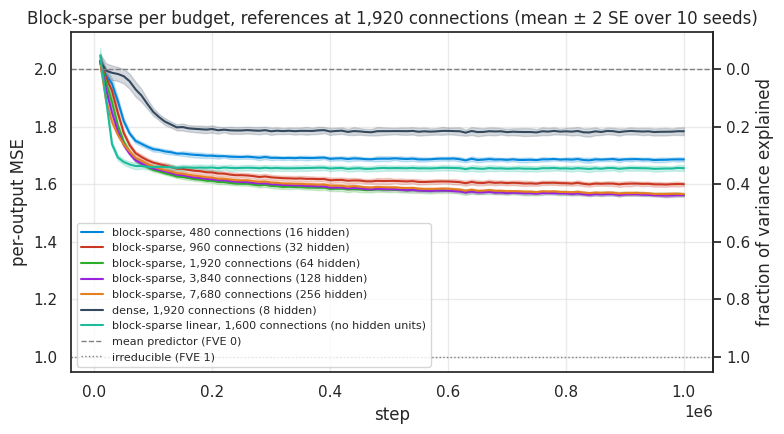

In [51]:
def plot_curves(runs):
    """Per-output MSE per run, mean ± 2 standard errors over seeds; the right axis reads FVE."""
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for label, res in runs.items():
        mean, sem = res['mse'].mean(0), res['mse'].std(0) / np.sqrt(N_SEEDS)
        ax.plot(res['steps'], mean, color=COLORS[label], label=label)
        ax.fill_between(res['steps'], mean - 2 * sem, mean + 2 * sem, color=COLORS[label], alpha=0.2)
    ax.axhline(BASELINE_MSE, ls='--', c='gray', lw=1, label='mean predictor (FVE 0)')
    ax.axhline(IRREDUCIBLE_MSE, ls=':', c='gray', lw=1, label='irreducible (FVE 1)')
    ax.secondary_yaxis('right', functions=(lambda m: 1.0 - (m - IRREDUCIBLE_MSE),
                                           lambda f: IRREDUCIBLE_MSE + 1.0 - f)
                       ).set_ylabel('fraction of variance explained')
    ax.set_xlabel('step')
    ax.set_ylabel('per-output MSE')
    ax.set_title(f'Block-sparse per budget, references at {REFERENCE_BUDGET:,} connections '
                 f'(mean ± 2 SE over {N_SEEDS} seeds)')
    ax.grid(alpha=0.4)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


plot_curves(runs)

### Did the budget hold?

Before reading anything else: 3b's connection count must stay at the budget. It is exactly
`BUDGET - deficit` at every step, so a deficit that does not sit near zero means `GEN_CAP` saturated
or proposals kept colliding, and the run trained a smaller network than intended. The crossing rate
is the same quantity for every run — in 3b every crossing is a prune, in the others it is only
counted.

In [52]:
def final(res, key, tail=0.1):
    """Mean of a per-block or per-snapshot series over the last `tail` of the run, over seeds."""
    values = np.asarray(res[key], dtype=np.float64)
    tail_values = values[:, -max(1, int(tail * values.shape[1])):]
    return float(np.nanmean(tail_values)) if np.isfinite(tail_values).any() else float("nan")


width = max(len(label) for label in runs)
print('final 10% of the run, per step where a rate')
for label, res in runs.items():
    print(f'  {label:<{width}}   connections {final(res, "n_connections"):7.1f}   '
          f'deficit: mean {res["deficit"].mean():6.2f}, worst step {res["max_deficit"].max():5.0f}   '
          f'sign changes {final(res, "n_crossed"):7.2f} '
          f'(same task {final(res, "n_crossed_useful"):6.2f}, cross task {final(res, "n_crossed_useless"):6.2f})   '
          f'pruned {final(res, "n_pruned"):6.2f}   of which hidden→output {final(res, "n_crossed_hidden_out"):5.2f}')

final 10% of the run, per step where a rate
  block-sparse, 480 connections (16 hidden)                  connections   480.0   deficit: mean   0.00, worst step     0   sign changes    2.70 (same task   2.70, cross task   0.00)   pruned   0.00   of which hidden→output  0.00
  block-sparse, 960 connections (32 hidden)                  connections   960.0   deficit: mean   0.00, worst step     0   sign changes   16.51 (same task  16.51, cross task   0.00)   pruned   0.00   of which hidden→output  0.00
  block-sparse, 1,920 connections (64 hidden)                connections  1920.0   deficit: mean   0.00, worst step     0   sign changes  229.26 (same task 229.26, cross task   0.00)   pruned   0.00   of which hidden→output  0.00
  block-sparse, 3,840 connections (128 hidden)               connections  3840.0   deficit: mean   0.00, worst step     0   sign changes 1070.44 (same task 1070.44, cross task   0.00)   pruned   0.00   of which hidden→output  0.00
  block-sparse, 7,680 connections (

### Structure over time

Does restructuring walk the network toward one subnetwork per task? Connectivity separation counts
paths from each output back to the inputs and asks what fraction land on its own subtask; signal
separation weights each path by the product of its weights; hidden-input purity looks at the hidden
layer alone, so it separates "the outputs happen to read clean paths" from "the hidden units have
specialized". Chance is 1/8 for all three, block-sparse is 1. In 3a the two connectivity-only metrics
are flat by construction; signal separation is the one line there that says anything about training.

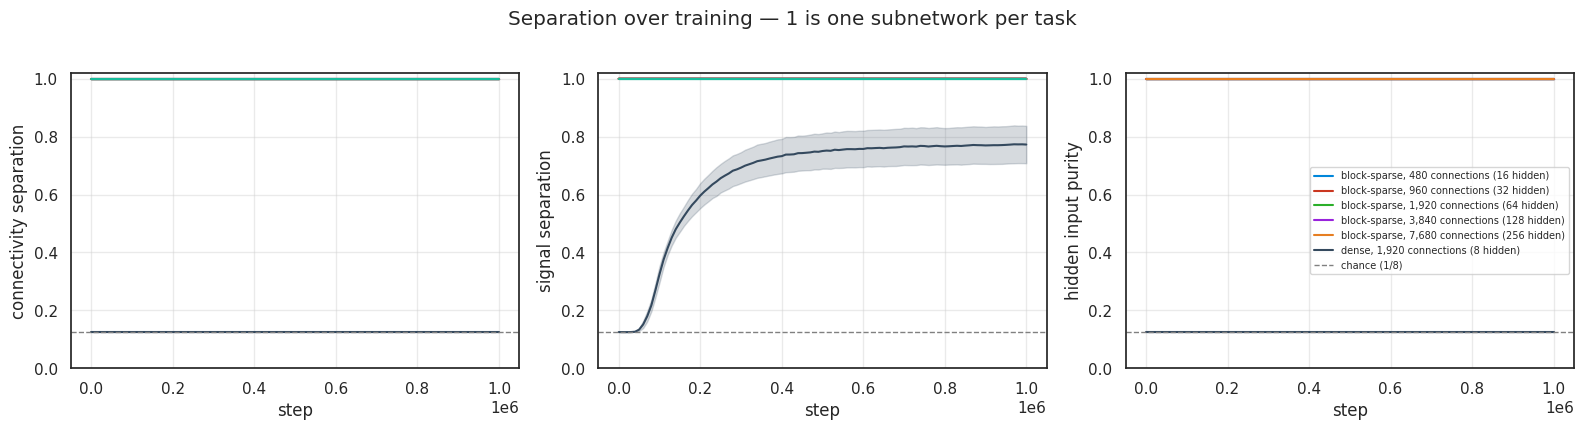

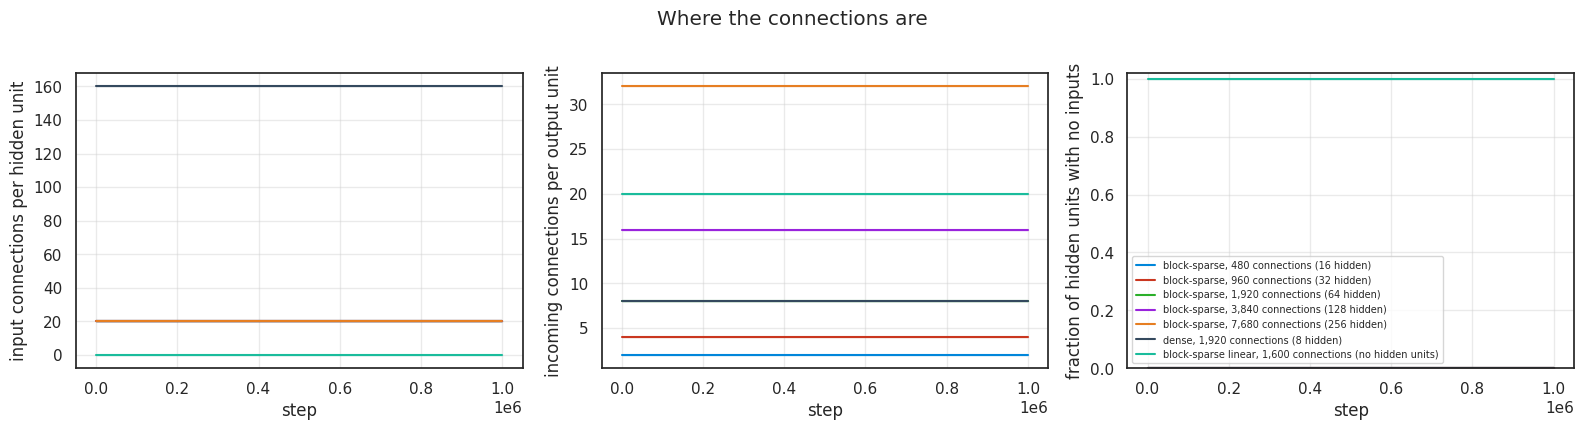

In [53]:
def plot_snapshot_metric(runs, key, ylabel, ax, hline=None, hline_label=None, ylim=None):
    """Mean over seeds ± 2 standard errors of a per-snapshot metric, one line per run."""
    for label, res in runs.items():
        values = np.asarray(res[key], dtype=np.float64)
        if not np.isfinite(values).any():                   # undefined for this structure
            continue
        mean, sem = np.nanmean(values, 0), np.nanstd(values, 0) / np.sqrt(N_SEEDS)
        ax.plot(res['snap_steps'], mean, color=COLORS[label], label=label)
        ax.fill_between(res['snap_steps'], mean - 2 * sem, mean + 2 * sem, color=COLORS[label],
                        alpha=0.2)
    if hline is not None:
        ax.axhline(hline, ls='--', c='gray', lw=1, label=hline_label)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_xlabel('step')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.4)


fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, (key, ylabel) in zip(axes, [('connectivity_separation', 'connectivity separation'),
                                    ('signal_separation', 'signal separation'),
                                    ('hidden_input_purity', 'hidden input purity')]):
    plot_snapshot_metric(runs, key, ylabel, ax, hline=1.0 / N_TASKS,
                         hline_label=f'chance (1/{N_TASKS})', ylim=(0, 1.02))
axes[-1].legend(fontsize=7, loc='best')
fig.suptitle('Separation over training — 1 is one subnetwork per task', y=1.02)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
plot_snapshot_metric(runs, 'hidden_incoming', 'input connections per hidden unit', axes[0])
plot_snapshot_metric(runs, 'output_incoming', 'incoming connections per output unit', axes[1])
plot_snapshot_metric(runs, 'dead_hidden_fraction', 'fraction of hidden units with no inputs',
                     axes[2], ylim=(0, 1.02))
axes[-1].legend(fontsize=7, loc='best')
fig.suptitle('Where the connections are', y=1.02)
fig.tight_layout()
plt.show()

### Step-sizes and weights of same-task vs. cross-task connections

The Experiment 1a view, as a distribution rather than individual traces, because in 3b the set of
connections changes underneath: median and inter-quantile bands over the *currently active*
connections of each kind and group, quantiles averaged over seeds. Blue should climb off the
initial step-size and red should stay near it. The third column holds the hidden→output
connections; in 3a and 3b those are only the protected same-task ones, so it has no red there. The
dense reference has no labels and is skipped.

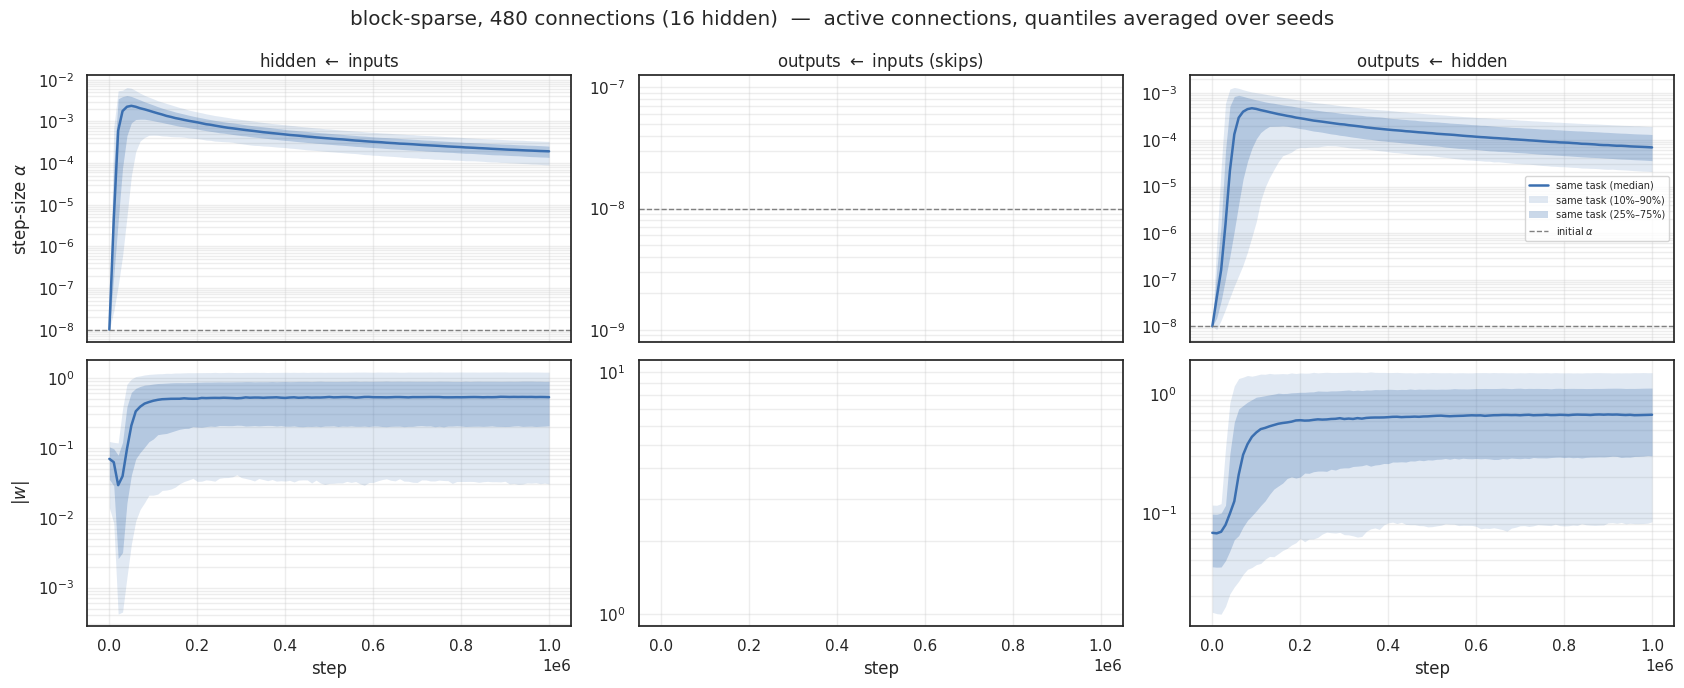

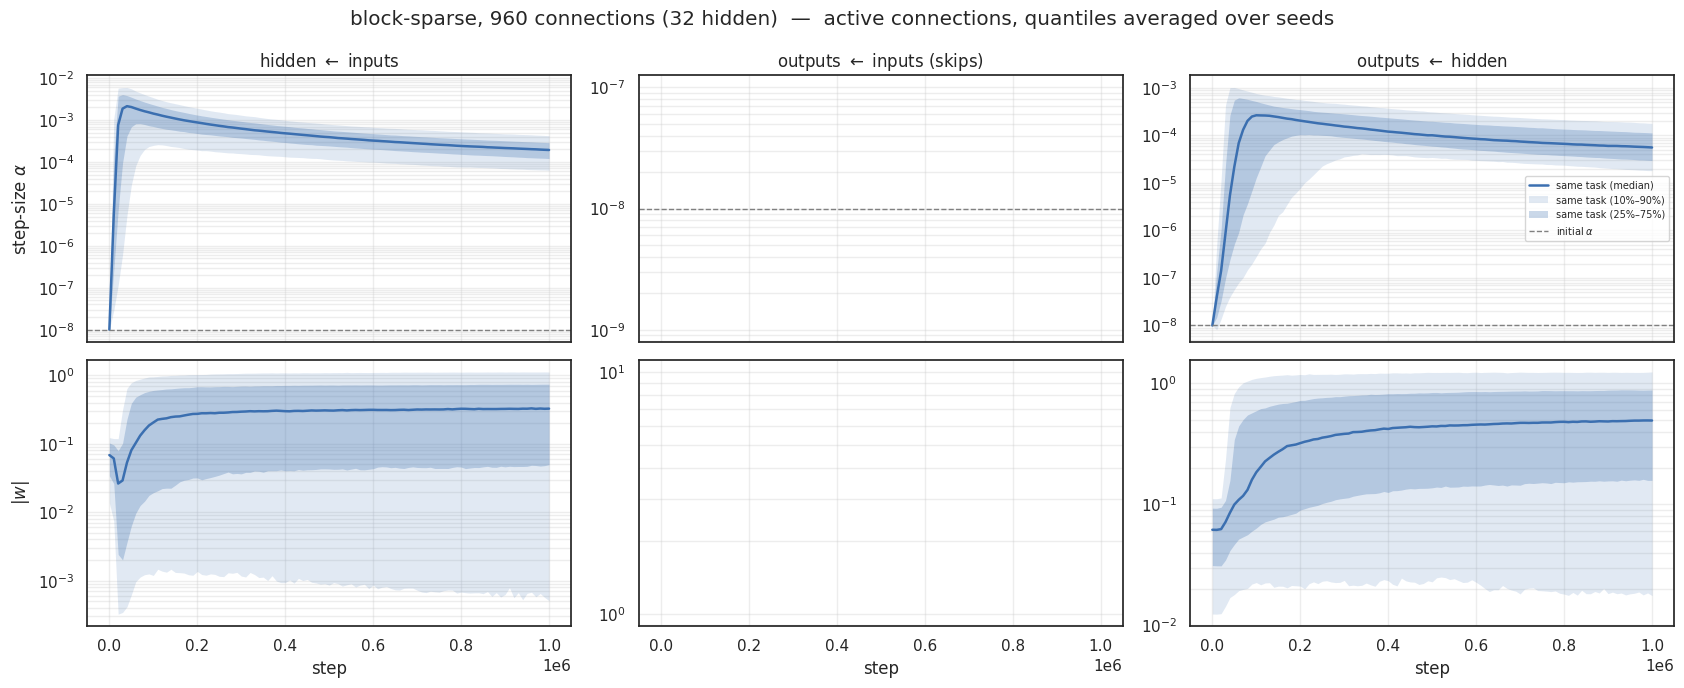

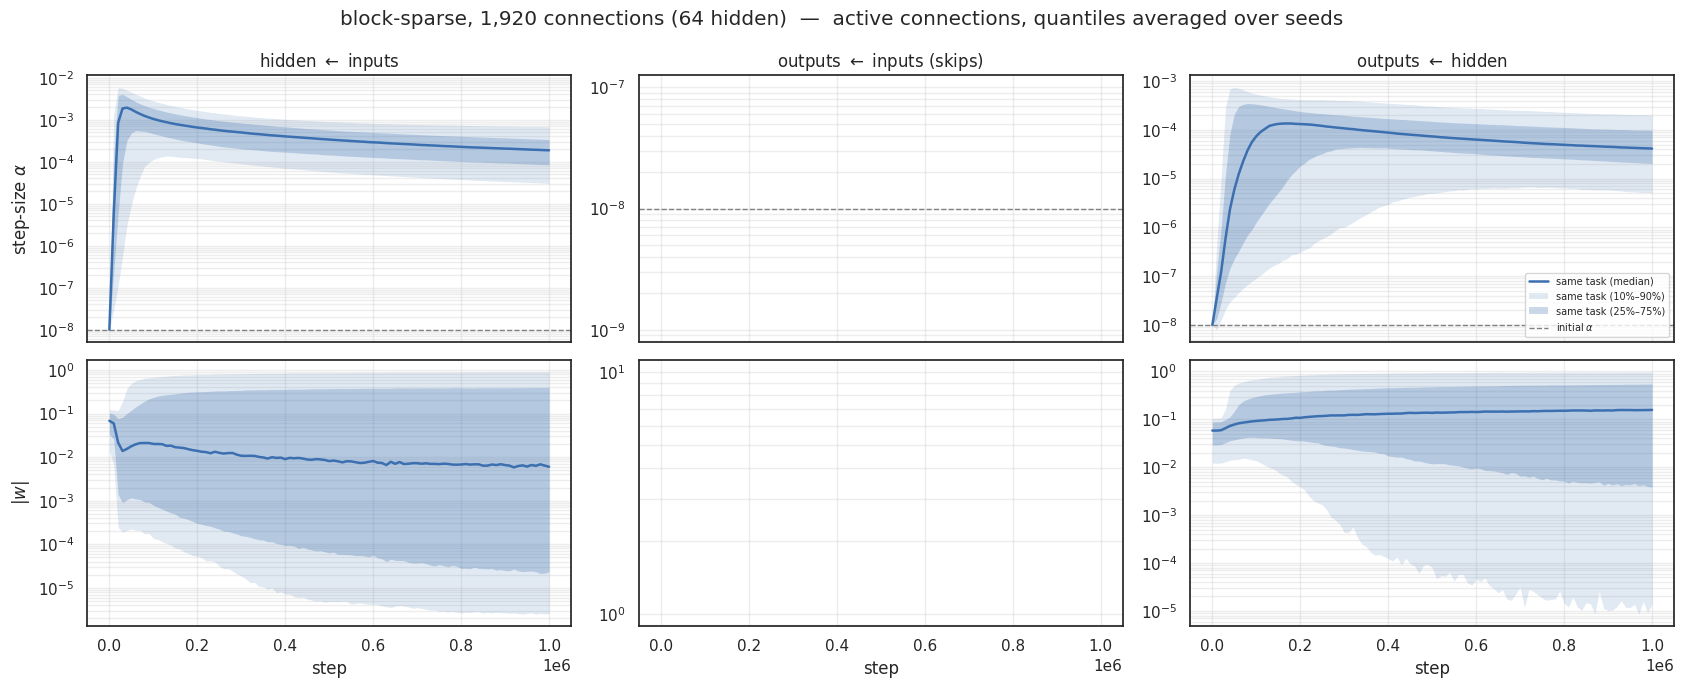

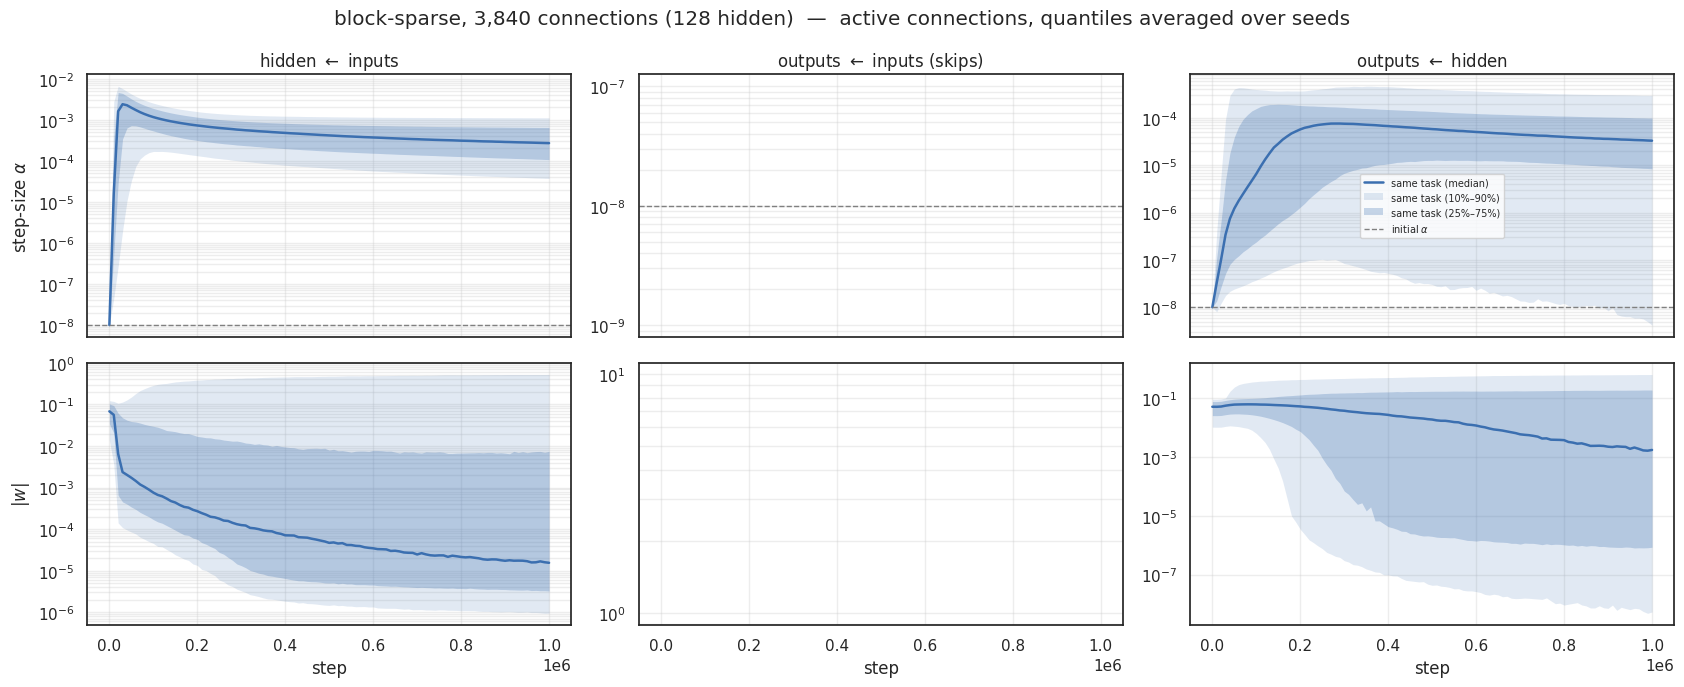

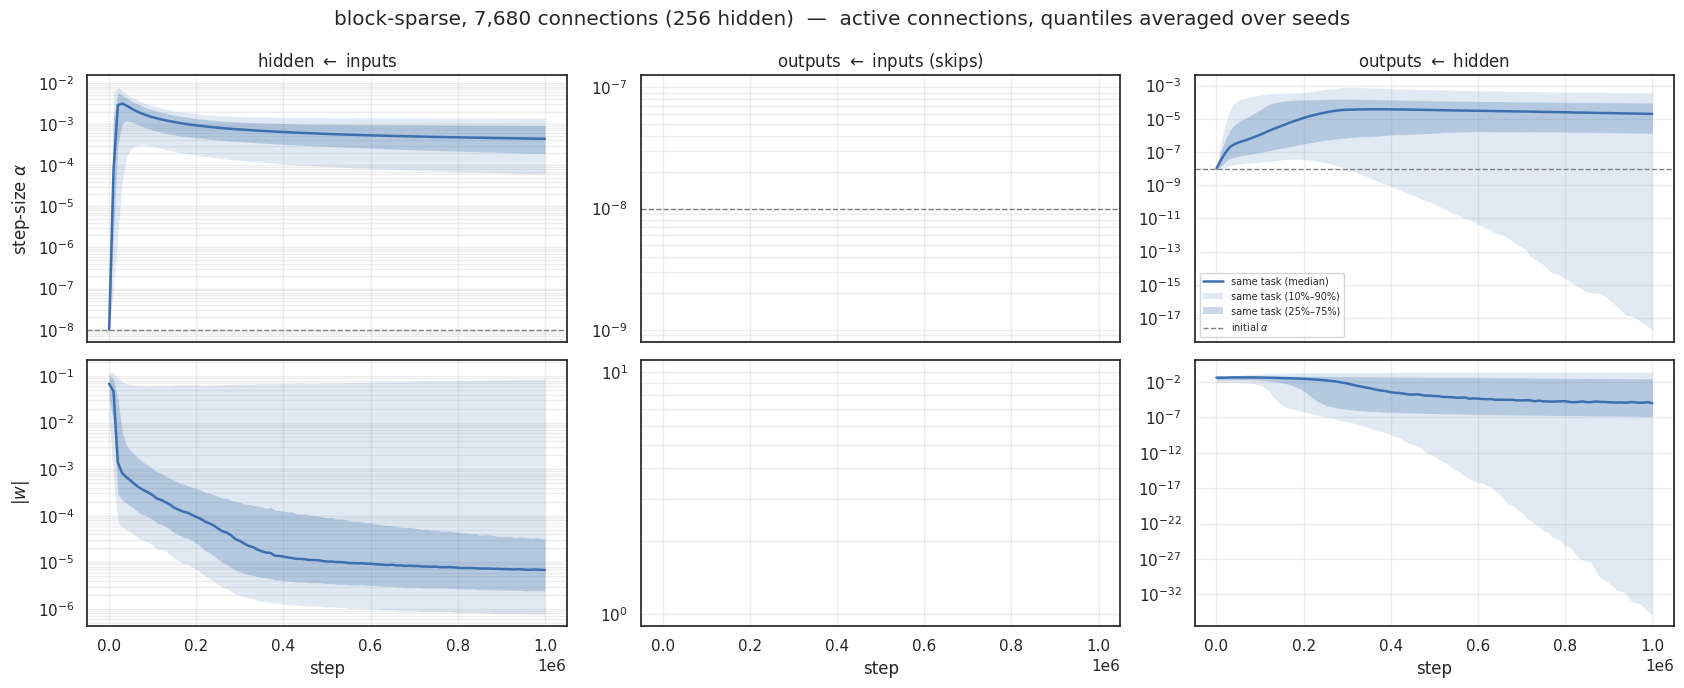

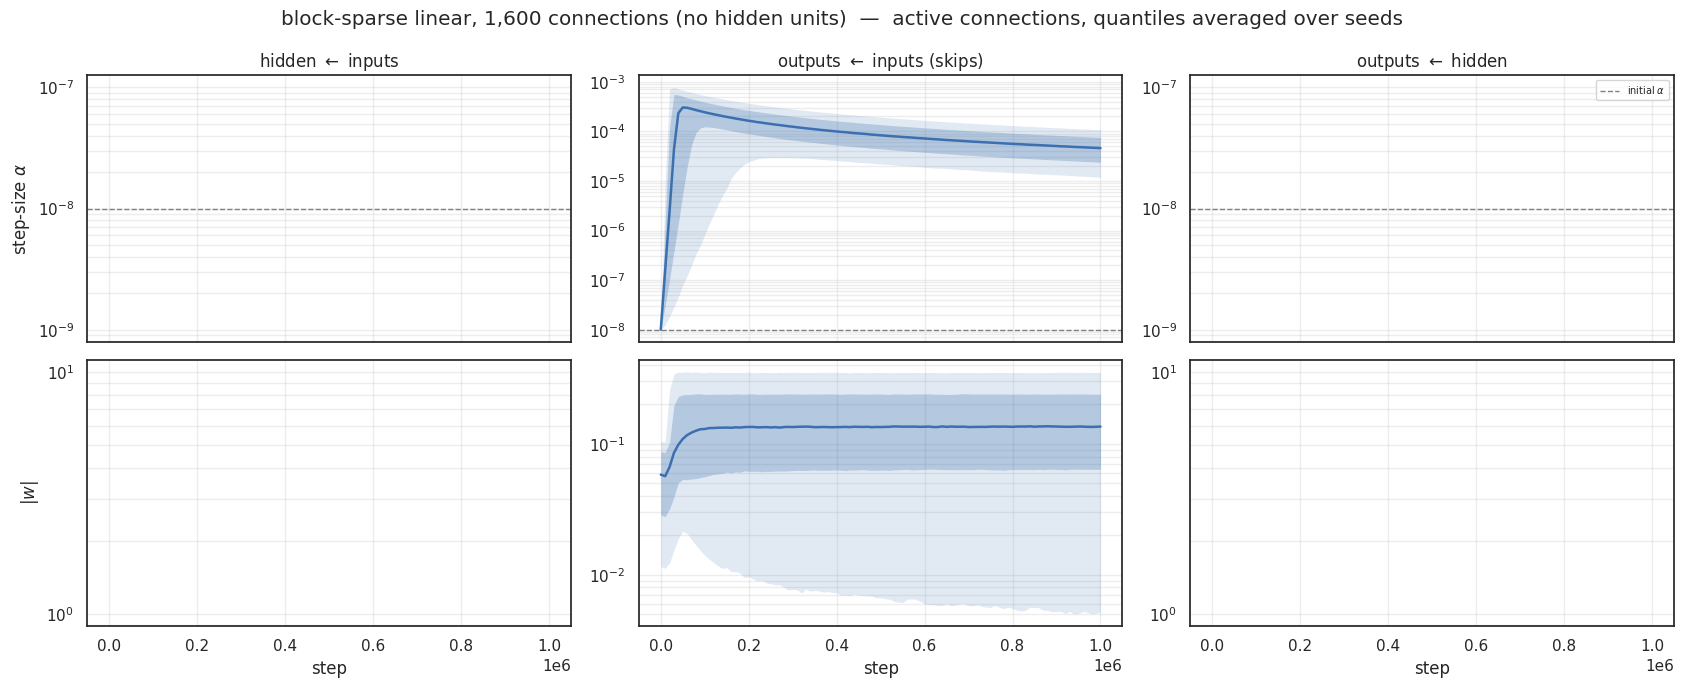

In [54]:
def plot_group_bands(res, title):
    """Median and inter-quantile bands of the step-size and |w| of the active connections, per kind."""
    rows = [('alpha_q', 'step-size $\\alpha$'), ('absw_q', '$|w|$')]
    fig, axes = plt.subplots(len(rows), len(VIEW_NAMES), figsize=(17, 7), sharex=True)
    mid = len(QUANTILES) // 2
    for row, (key, ylabel) in enumerate(rows):
        with warnings.catch_warnings():                     # a group with no connections is all NaN
            warnings.simplefilter('ignore', RuntimeWarning)
            q = np.nanmean(np.asarray(res[key], dtype=np.float64), axis=0)   # (snapshot, view, group, q)
        for col, layer_name in enumerate(VIEW_NAMES):
            ax = axes[row, col]
            for group, (name, color) in enumerate(zip(GROUP_NAMES, GROUP_COLORS)):
                curves = q[:, col, group, :]
                if not np.isfinite(curves).any():
                    continue
                ax.plot(res['snap_steps'], curves[:, mid], color=color, lw=1.8,
                        label=f'{name} (median)')
                for depth, (lo, hi) in enumerate(zip(range(mid), range(len(QUANTILES) - 1, mid, -1))):
                    ax.fill_between(res['snap_steps'], curves[:, lo], curves[:, hi], color=color,
                                    lw=0, alpha=0.15 + 0.12 * depth,
                                    label=f'{name} ({QUANTILES[lo]:.0%}–{QUANTILES[hi]:.0%})')
            ax.set_yscale('log')
            if key == 'alpha_q':
                ax.axhline(INIT_LR, ls='--', c='gray', lw=1, label='initial $\\alpha$')
            ax.grid(alpha=0.35, which='both')
            ax.set_title(layer_name if row == 0 else '')
            ax.set_xlabel('step' if row == len(rows) - 1 else '')
            ax.set_ylabel(ylabel if col == 0 else '')
    axes[0, -1].legend(fontsize=7)
    fig.suptitle(f'{title}  —  active connections, quantiles averaged over seeds')
    fig.tight_layout()
    plt.show()


for label, res in runs.items():
    if np.isfinite(np.asarray(res['alpha_q'], dtype=np.float64)).any():   # dense has no labels, so no bands
        plot_group_bands(res, label)

### Turnover

How many input connections change sign per step, split by group. In 3b every sign change is a prune
and a regeneration, so this is the rate at which the structure is being recycled: a rate that never
falls means connections are replaced faster than they can prove themselves. In 3a the same events
are counted but nothing is pruned, which shows what the prune rule *would* have done to a fixed
structure.

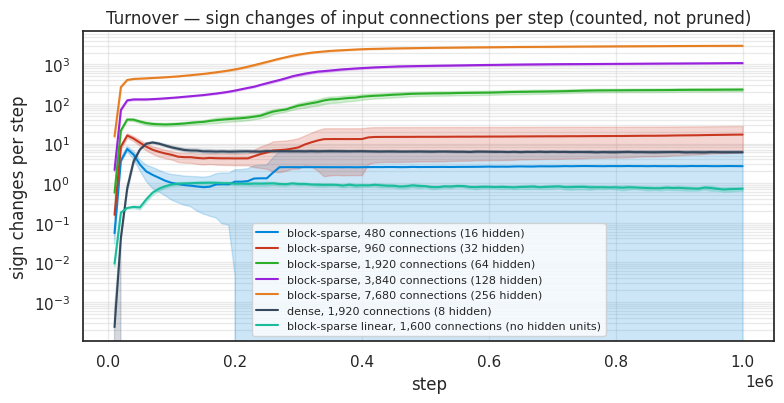

In [55]:
fig, ax = plt.subplots(figsize=(8, 4.2))
for label, res in runs.items():
    values = np.asarray(res['n_crossed'], dtype=np.float64)
    mean, sem = values.mean(0), values.std(0) / np.sqrt(N_SEEDS)
    ax.plot(res['steps'], mean, color=COLORS[label], label=label)
    ax.fill_between(res['steps'], mean - 2 * sem, mean + 2 * sem, color=COLORS[label], alpha=0.2)
ax.set_yscale('log')
ax.set_xlabel('step')
ax.set_ylabel('sign changes per step')
ax.grid(alpha=0.4, which='both')
ax.legend(fontsize=8)
ax.set_title('Turnover — sign changes of input connections per step (counted, not pruned)')
fig.tight_layout()
plt.show()


### Summary

Everything over the final 10% of the run.

In [56]:
rows = []
for label, res in runs.items():
    mse = final(res, 'mse')
    rows.append({'run': label, 'MSE': mse, 'FVE': 1.0 - (mse - IRREDUCIBLE_MSE),
                 'conn. sep.': final(res, 'connectivity_separation'),
                 'signal sep.': final(res, 'signal_separation'),
                 'purity': final(res, 'hidden_input_purity'),
                 'in/hidden': final(res, 'hidden_incoming'),
                 'out/hidden': final(res, 'hidden_outgoing'),
                 'in/output': final(res, 'output_incoming'),
                 'dead hidden': final(res, 'dead_hidden_fraction'),
                 'connections': final(res, 'n_connections'),
                 'sign changes/step': final(res, 'n_crossed'),
                 'pruned/step': final(res, 'n_pruned')})
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f'{v:.4g}'))

                                                     run   MSE    FVE  conn. sep.  signal sep.  purity  in/hidden  out/hidden  in/output  dead hidden  connections  sign changes/step  pruned/step
               block-sparse, 480 connections (16 hidden) 1.686 0.3144           1            1       1         20          10          2            0          480              2.698            0
               block-sparse, 960 connections (32 hidden)   1.6 0.3996           1            1       1         20          10          4            0          960              16.51            0
             block-sparse, 1,920 connections (64 hidden) 1.565 0.4352           1            1       1         20          10          8            0         1920              229.3            0
            block-sparse, 3,840 connections (128 hidden) 1.562 0.4377           1            1       1         20          10         16            0         3840               1070            0
            block-sparse,

### 3c — fixed in-degree, feedback first, then backpropagation

3c differs from 3b in where a replacement goes: on the unit that just lost the connection, with a new
random source, so every hidden and output unit keeps its initial number of incoming connections and
the budget cannot drift between units or between kinds of connection. For the first `FEEDBACK_STEPS`
steps the error still comes through the fixed feedback. After that the hidden units' error comes
through the actual hidden→output weights, an output unit's replacement may draw a hidden unit as its
source, and those generated hidden→output connections are pruned on a sign change like any input
connection. Each hidden unit's initial output connection stays protected, so no hidden unit ever
loses its task. The questions: does the switch cost anything (the learning curve against 3b); do
output units take on extra hidden sources, and do the cross-task ones get pruned again (outgoing
connections per hidden unit, and the hidden→output sign changes); and do the hidden→output step-sizes
and weights separate by group the way the input connections do (the third column of the bands).

In [57]:
pair = {label: runs[label] for label in ('3b — learned connectivity', LABEL_3C)}
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
for label, res in pair.items():
    mean, sem = res['mse'].mean(0), res['mse'].std(0) / np.sqrt(N_SEEDS)
    axes[0].plot(res['steps'], mean, color=COLORS[label], label=label)
    axes[0].fill_between(res['steps'], mean - 2 * sem, mean + 2 * sem, color=COLORS[label], alpha=0.2)
axes[0].set_xlabel('step')
axes[0].set_ylabel('per-output MSE')
axes[0].grid(alpha=0.4)
axes[0].legend(fontsize=7)

plot_snapshot_metric(pair, 'hidden_outgoing', 'outgoing connections per hidden unit', axes[1],
                     hline=1.0, hline_label='the protected one')
axes[1].legend(fontsize=7)

res = runs[LABEL_3C]
kinds = ((np.asarray(res['n_crossed'] - res['n_crossed_hidden_out'], dtype=np.float64),
          'input connections', '#555555'),
         (np.asarray(res['n_crossed_hidden_out'], dtype=np.float64),
          'hidden $\\rightarrow$ output', '#8e44ad'))
for values, name, color in kinds:
    mean, sem = values.mean(0), values.std(0) / np.sqrt(N_SEEDS)
    axes[2].plot(res['steps'], mean, color=color, label=name)
    axes[2].fill_between(res['steps'], mean - 2 * sem, mean + 2 * sem, color=color, alpha=0.2)
axes[2].set_yscale('log')
axes[2].set_xlabel('step')
axes[2].set_ylabel('sign changes per step in 3c')
axes[2].grid(alpha=0.4, which='both')
axes[2].legend(fontsize=7)

for ax in axes:
    ax.axvline(FEEDBACK_STEPS, ls=':', c='k', lw=1)
fig.suptitle(f'3c — the switch to backpropagation at step {FEEDBACK_STEPS:,} (dotted line)', y=1.02)
fig.tight_layout()
plt.show()

plot_group_bands(runs[LABEL_3C], LABEL_3C)

KeyError: '3b — learned connectivity'